In [13]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [14]:
import pandas as pd

df = pd.read_parquet(
    "/home/ubun/dev/llvm-autotuner/results/baselines.parquet"
)

merged = (
    df.groupby(["bench", "level"], as_index=False)
      .agg({
          "instr": "max",
          "median_s": "max",
          "stddev_s": "max"
      })
)

merged.head()

,bench,level,instr,median_s,stddev_s
0,2mm,O0,50943446.0,NaN,NaN
1,2mm,O2,6061413.0,0.010737,0.001854
2,2mm,O3,5997876.0,0.010227,0.001565
3,2mm,Os,17100140.0,NaN,NaN
4,3mm,O0,51183117.0,NaN,NaN


In [15]:
pivot = merged.pivot(
    index="bench",
    columns="level",
    values="instr"
)
pivot.columns.name = None
pivot.index.name = None

pivot

,O0,O2,O3,Os
2mm,50943446.0,6061413.0,5997876.0,17100140.0
3mm,51183117.0,6111993.0,6013848.0,17165179.0
atax,50628232.0,5982287.0,5979873.0,17002486.0
bicg,50619706.0,5988559.0,5988536.0,16999322.0
correlation,50967611.0,6039999.0,6015165.0,17076307.0
covariance,50944212.0,6032761.0,6011066.0,17069941.0
gemm,51006676.0,6045678.0,6069622.0,17122083.0
gesummv,50586637.0,5979420.0,5979408.0,16997189.0
heat-3d,53341573.0,6406158.0,6331289.0,17417427.0
jacobi-2d,52291460.0,6169510.0,6135545.0,17263341.0


In [16]:
pivot["O0_vs_O2"] = pivot["O0"] / pivot["O2"]
pivot["O0_vs_O3"] = pivot["O0"] / pivot["O3"]
pivot["O2_vs_O3"] = pivot["O2"] / pivot["O3"]

pivot[["O0_vs_O2", "O0_vs_O3", "O2_vs_O3"]]

,O0_vs_O2,O0_vs_O3,O2_vs_O3
2mm,8.404550,8.493581,1.010593
3mm,8.374211,8.510876,1.016320
atax,8.463023,8.466439,1.000404
bicg,8.452736,8.452768,1.000004
correlation,8.438348,8.473186,1.004129
covariance,8.444593,8.475071,1.003609
gemm,8.436883,8.403600,0.996055
gesummv,8.460124,8.460141,1.000002
heat-3d,8.326609,8.425073,1.011825
jacobi-2d,8.475788,8.522708,1.005536


In [17]:
from src.autotuner.stats import geomean

print("GeoMean O0/O2:", geomean(pivot["O0_vs_O2"]))
print("GeoMean O0/O3:", geomean(pivot["O0_vs_O3"]))
print("GeoMean O2/O3:", geomean(pivot["O2_vs_O3"]))

GeoMean O0/O2: 8.40857151509712
GeoMean O0/O3: 8.442677676127865
GeoMean O2/O3: 1.0040561183275316


In [18]:
pivot["O2_vs_O3"].sort_values()

gemm           0.996055
mvt            0.999998
gesummv        1.000002
bicg           1.000004
seidel-2d      1.000395
atax           1.000404
covariance     1.003609
correlation    1.004129
jacobi-2d      1.005536
2mm            1.010593
heat-3d        1.011825
3mm            1.016320
Name: O2_vs_O3, dtype: float64

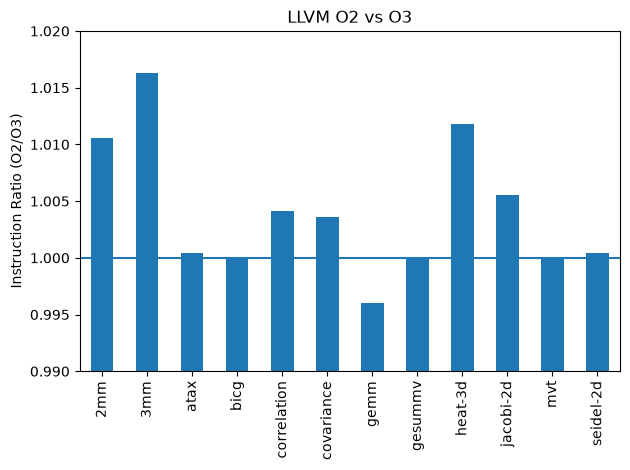

In [25]:
import matplotlib.pyplot as plt

pivot["O2_vs_O3"].plot(kind="bar")

plt.axhline(y=1.0)

plt.ylim(0.99, 1.02)

plt.ylabel("Instruction Ratio (O2/O3)")
plt.title("LLVM O2 vs O3")

plt.tight_layout()
plt.savefig("/home/ubun/dev/llvm-autotuner/plots/baseline_O2_O3.png", dpi=300)
plt.show()

LLVM's standard optimization levels are very close to each other.
However, some benchmarks slightly prefer O2 and others slightly prefer O3.
Therefore benchmark-specific pass tuning may outperform both.

In [26]:
pivot[["O0", "O2", "O3", "Os"]].idxmin(axis=1)

2mm            O3
3mm            O3
atax           O3
bicg           O3
correlation    O3
covariance     O3
gemm           O2
gesummv        O3
heat-3d        O3
jacobi-2d      O3
mvt            O2
seidel-2d      O3
dtype: str

In [29]:
summary = pivot[[
    "O0_vs_O2",
    "O0_vs_O3",
    "O2_vs_O3"
]].round(3)
summary.to_csv("/home/ubun/dev/llvm-autotuner/results/baseline_summary.csv")
summary

,O0_vs_O2,O0_vs_O3,O2_vs_O3
2mm,8.405,8.494,1.011
3mm,8.374,8.511,1.016
atax,8.463,8.466,1.000
bicg,8.453,8.453,1.000
correlation,8.438,8.473,1.004
covariance,8.445,8.475,1.004
gemm,8.437,8.404,0.996
gesummv,8.460,8.460,1.000
heat-3d,8.327,8.425,1.012
jacobi-2d,8.476,8.523,1.006


In [3]:
import pandas as pd

rand = pd.read_parquet(
    "/home/ubun/dev/llvm-autotuner/results/search_random.parquet"
)

hill = pd.read_parquet(
    "/home/ubun/dev/llvm-autotuner/results/search_hillclimb.parquet"
)

rand_best = (
    rand.groupby("bench")["best_so_far"]
        .min()
        .reset_index()
        .rename(columns={"best_so_far": "random"})
)

hill_best = (
    hill.groupby("bench")["best_so_far"]
        .min()
        .reset_index()
        .rename(columns={"best_so_far": "hill"})
)

cmp = rand_best.merge(hill_best, on="bench")

cmp["hill_vs_random"] = cmp["hill"] / cmp["random"]

cmp.sort_values("hill_vs_random")

,bench,random,hill,hill_vs_random
8,heat-3d,11838602,10273004,0.867755
11,seidel-2d,11154147,10591844,0.949588
9,jacobi-2d,11018104,10586221,0.960802
1,3mm,10276818,10037561,0.976719
6,gemm,10121499,9888070,0.976937
0,2mm,10043830,9914425,0.987116
5,covariance,10022402,9969710,0.994743
4,correlation,10038406,9991378,0.995315
2,atax,9725555,9683032,0.995628
10,mvt,9725506,9695886,0.996954


In [4]:
import numpy as np

gmean = np.exp(np.log(cmp["hill_vs_random"]).mean())

print("GeoMean Hill/Random:", gmean)
print("Average improvement:", (1-gmean)*100, "%")

GeoMean Hill/Random: 0.9741329516551154
Average improvement: 2.5867048344884624 %


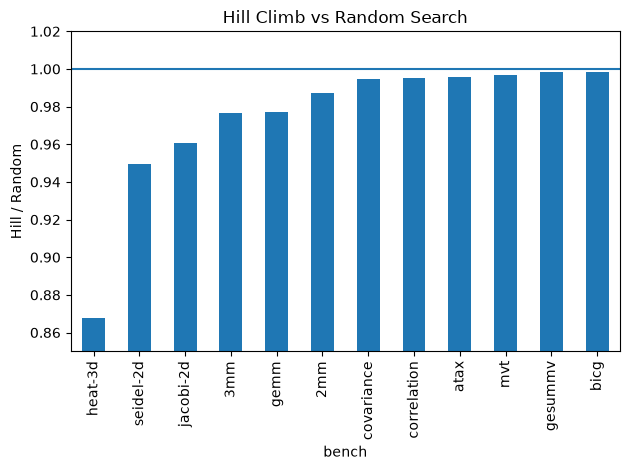

In [8]:
import matplotlib.pyplot as plt

cmp = cmp.sort_values("hill_vs_random")

cmp.plot(
    x="bench",
    y="hill_vs_random",
    kind="bar",
    legend=False
)

plt.axhline(y=1.0)
plt.ylim(0.85, 1.02)
plt.ylabel("Hill / Random")
plt.title("Hill Climb vs Random Search")

plt.tight_layout()
plt.savefig(
    "/home/ubun/dev/llvm-autotuner/plots/hill_vs_random.png",
    dpi=300
)
plt.show()

Hill Climbing consistently outperformed Random Search across all 12 PolyBench benchmarks. Every benchmark achieved a Hill/Random ratio below 1.0, indicating lower instruction counts. The largest improvements were observed for stencil kernels such as Heat-3D (13.2%), Seidel-2D (5.0%), and Jacobi-2D (4.0%), while dense linear algebra kernels showed smaller gains. Overall, Hill Climbing achieved a 2.59% geometric-mean reduction in instruction count, demonstrating that exploiting feedback from previous evaluations is more effective than purely random exploration of LLVM pass sequences.

GeoMean Hill/Random = 0.9741
Average improvement = 2.59%
Best benchmark gain = 13.2% (heat-3d)
Benchmarks evaluated = 12
Budget = 60 evaluations/benchmark